In [15]:
import setup
from importlib import reload
reload(setup)
from setup import *

# ER 2 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.42,15
,3000,0,0.42,3
,3000,0,0.43,7
,3000,0,0.47,15


Computed from 4000 posterior samples and 1404 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  3401.57    54.23
p_loo        6.84        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1404  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



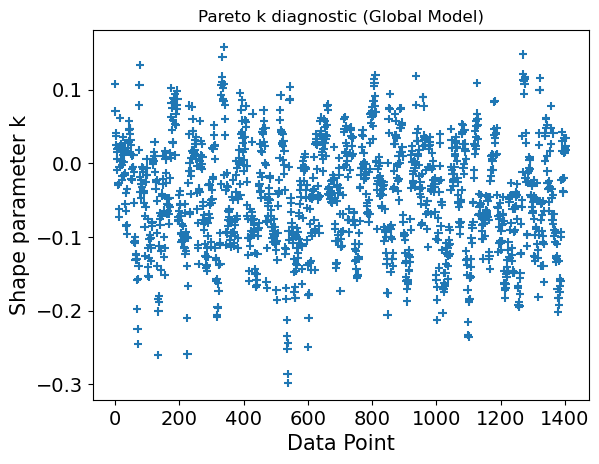

In [2]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    rate = observables(log_rate) 

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.148  0.001  -0.149   -0.146      0.000    0.000    2605.0    2528.0    1.0
deltaG4_0   0.105  0.002   0.101    0.110      0.000    0.000    2717.0    2743.0    1.0
Gact2_0     0.769  0.000   0.769    0.770      0.000    0.000    3472.0    2730.0    1.0
beta_2      0.323  0.002   0.319    0.327      0.000    0.000    3248.0    2933.0    1.0
sigma_rel   0.131  0.007   0.118    0.144      0.000    0.000    1741.0    2379.0    1.0
sigma_base  0.000  0.000   0.000    0.000      0.000    0.000    2125.0    1314.0    1.0
exponent    1.495  0.035   1.429    1.558      0.001    0.001    1734.0    2254.0    1.0


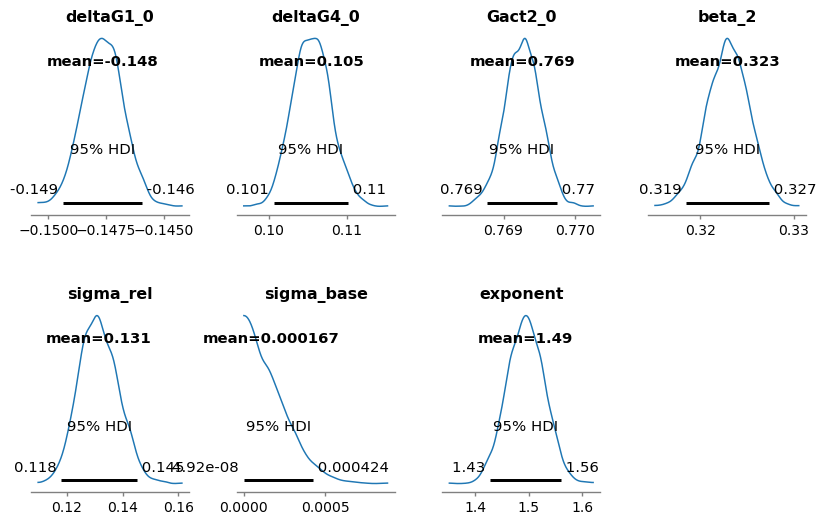

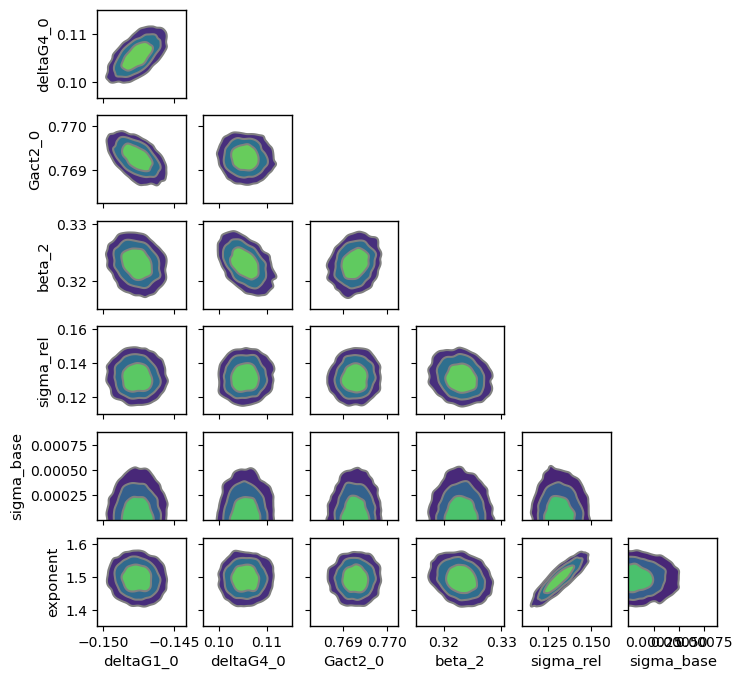

Sampling: [rate]


rate: 0.909


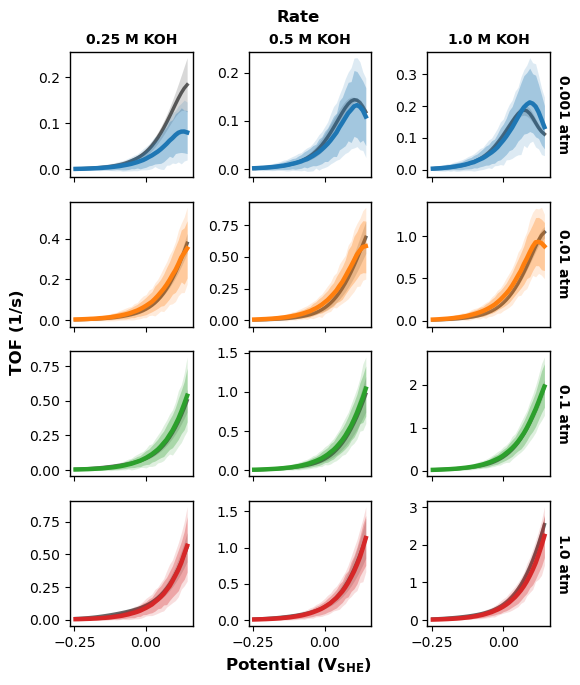

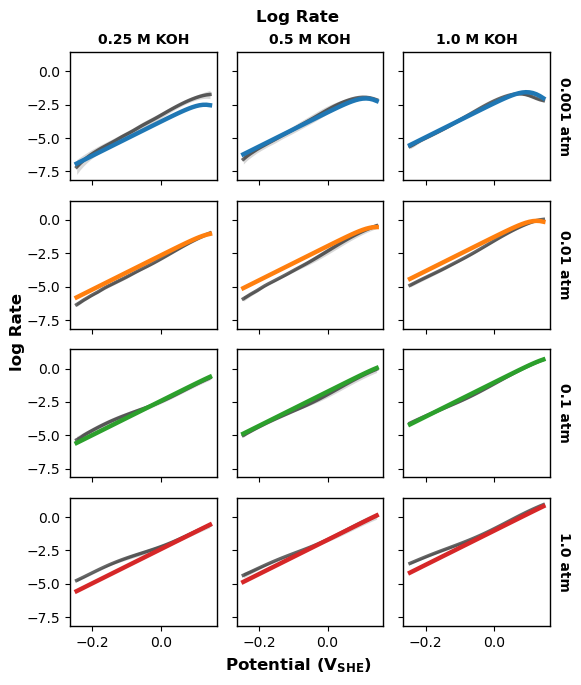

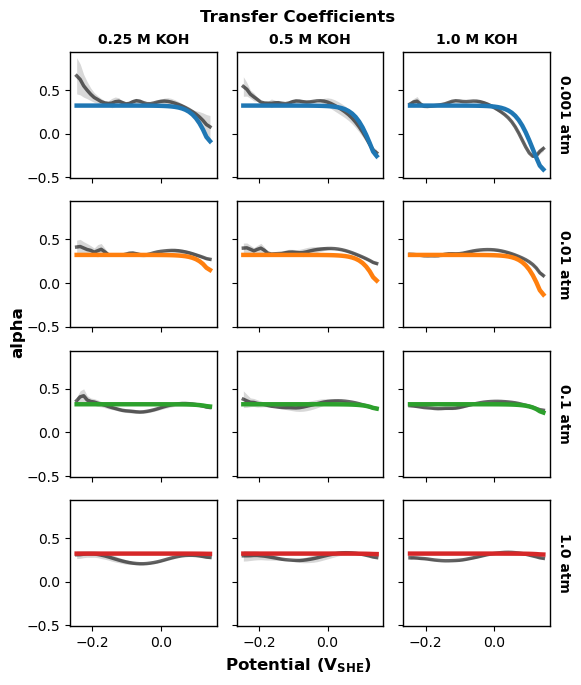

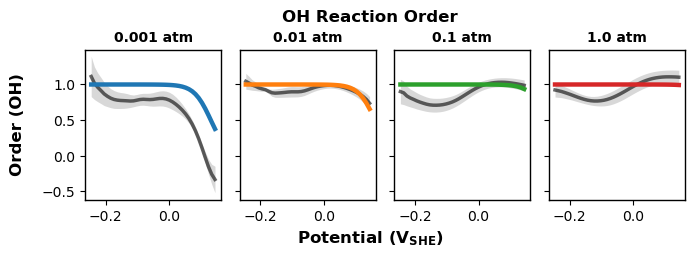

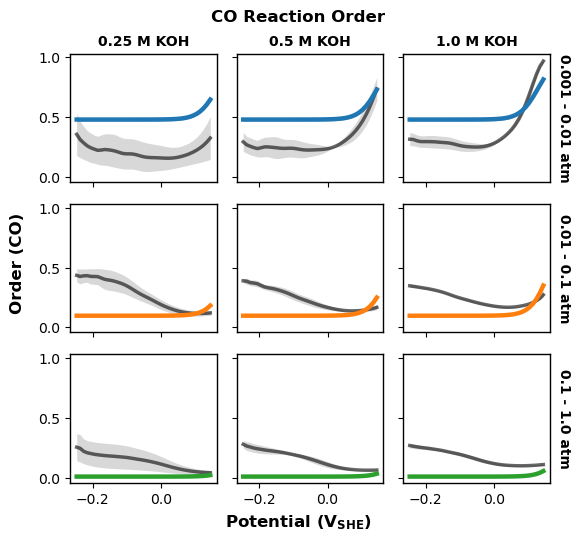

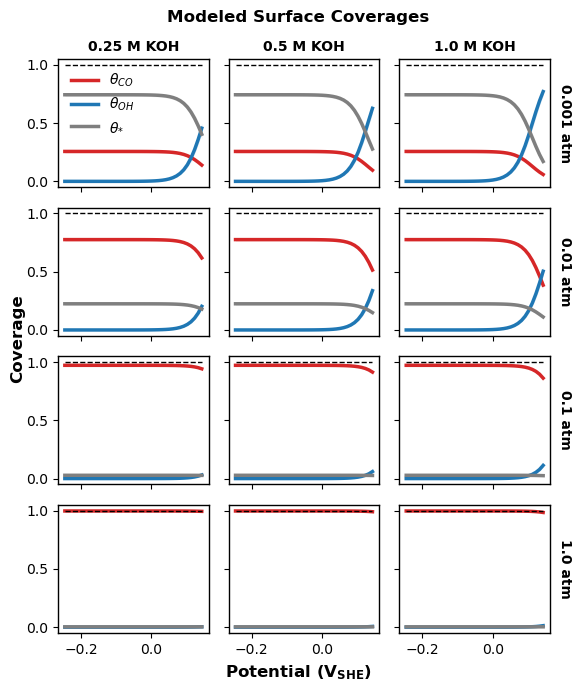

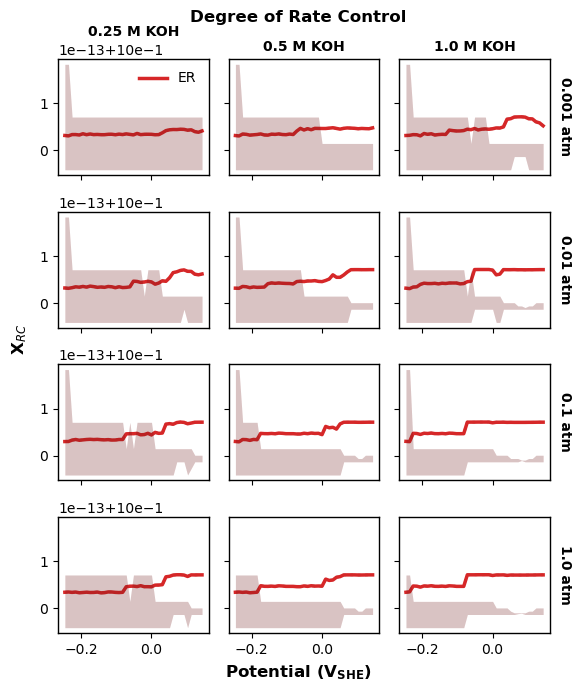

In [16]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2)
plot_model_fits(trace_ER_2, ppc_ER_2); plot_coverages(trace_ER_2)
plot_drc(ER_2, trace_ER_2, perturb_vars=['Gact2_0'], perturb_labels=['ER'])

# Comparison

In [4]:
comparison_dict = {
    # "ER_2": loo_ER_2,
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()

KeyError: 'elpd_loo'